In [ ]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
import h5py
import numpy as np
from tensorflow.keras import utils

class DataManager:
    def __init__(self, hdf5_path):
        self.hdf5_path = hdf5_path

    def load_from_hdf5(self):
        """Завантажуємо з HDF5 файл зображення, метадані та мітки"""
        with h5py.File(self.hdf5_path, "r") as f:
            images = f["images"][:].astype(np.float32)
            labels = f["ans"][:]

            ra = f["ra"][:]
            dec = f["dec"][:]
            redshift = f["redshift"][:]
            pxscale = f["pxscale"][:]
            labels = utils.to_categorical(labels, 10).astype(np.float32)
            
            return [
                {
                    "image": images[i],
                    "label": labels[i],
                    "metadata": {
                        "ra": ra[i],
                        "dec": dec[i],
                        "redshift": redshift[i],
                        "pxscale": pxscale[i]
                    }
                }
                for i in range(images.shape[0])
            ]


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\Anya\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Anya\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "d:\ДИПЛОМ_ДІН\.venv\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\ДИПЛОМ_ДІН\.venv\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\Anya\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Anya\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "d:\ДИПЛОМ_ДІН\.venv\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\ДИПЛОМ_ДІН\.venv\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\Anya\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Anya\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "d:\ДИПЛОМ_ДІН\.venv\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\ДИПЛОМ_ДІН\.venv\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start

AttributeError: _UFUNC_API not found

ImportError: numpy.core.umath failed to import

TypeError: Unable to convert function return value to a Python type! The signature was
	() -> handle

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import os
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
from tensorflow.keras import layers, models

METADATA_INCLUDED = False
images_path = "..\\data\\Galaxy10_DECals.h5"
data_manager = DataManager(images_path)
dataset = data_manager.load_from_hdf5()



In [ ]:
from astroNN.datasets.galaxy10 import galaxy10cls_lookup
import pandas as pd
df = pd.DataFrame({
    "ra": [item["metadata"]["ra"] for item in dataset],
    "dec": [item["metadata"]["dec"] for item in dataset],
    "redshift": [item["metadata"]["redshift"] for item in dataset],
    "pxscale": [item["metadata"]["pxscale"] for item in dataset],
    "label": [np.argmax(item["label"]) for item in dataset],
    "image": [item["image"]/255.0 for item in dataset],
    "label_name": [galaxy10cls_lookup(item["label"]) for item in dataset]
})



d:\ДИПЛОМ_ДІН\.venv\Lib\site-packages\astroNN\__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [ ]:
df.head()

,ra,dec,redshift,pxscale,label,image,label_name
0,331.664055,-0.484155,0.081919,0.262,0,"[[[0.26666668, 0.07450981, 0.09019608], [0.227...",Disturbed
1,334.536578,-1.189031,0.115252,0.262,0,"[[[0.07450981, 0.101960786, 0.16470589], [0.05...",Disturbed
2,341.902490,-1.127418,0.109418,0.262,0,"[[[0.16078432, 0.25882354, 0.2784314], [0.1529...",Disturbed
3,341.343305,0.658176,0.106816,0.262,0,"[[[0.09803922, 0.19215687, 0.13725491], [0.145...",Disturbed
4,349.189982,0.926543,0.120056,0.262,0,"[[[0.09411765, 0.15686275, 0.11372549], [0.094...",Disturbed


In [ ]:
sample = df.sample(5000)

<Axes: xlabel='label_name'>

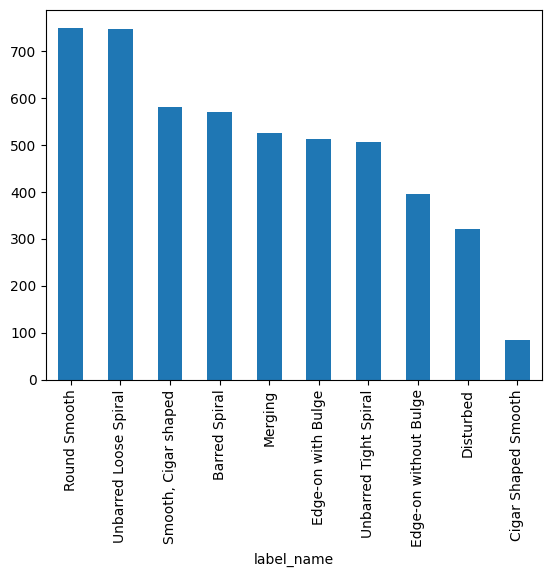

In [ ]:
sample["label_name"].value_counts().plot(kind="bar")

In [ ]:
images = np.array(sample["image"].tolist())
labels = np.array(sample["label"].tolist())

train_idx, test_idx = train_test_split(np.arange(labels.shape[0]), test_size=0.25)
train_images, train_labels, test_images, test_labels = images[train_idx], labels[train_idx], images[test_idx], labels[test_idx]

print(f"Train set: {train_images.shape}, {train_labels.shape}")
print(f"Test set: {test_images.shape}, {test_labels.shape}")



Train set: (3750, 256, 256, 3), (3750,)
Test set: (1250, 256, 256, 3), (1250,)


In [ ]:
train_labels = utils.to_categorical(train_labels, 10)
test_labels = utils.to_categorical(test_labels, 10)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256,256,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Classification
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


d:\ДИПЛОМ_ДІН\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=180,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2
)

datagen.fit(train_images)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(datagen.flow(train_images, train_labels, batch_size=32),
          epochs=30,
          validation_data=(test_images, test_labels))

Epoch 1/30
  4/118 ━━━━━━━━━━━━━━━━━━━━ 2:56 2s/step - accuracy: 0.1191 - loss: 3.1567

KeyboardInterrupt: 

In [ ]:
img_array = dataset[5]["image"].reshape(1, 256, 256, 3)  # reshape to (1, height, width, channels)
print("Image array shape:", img_array.shape)
pred_probs = model.predict(img_array)  # returns probabilities for each class
print("Probabilities:", pred_probs)
pred_class = np.argmax(pred_probs)  # returns the index of the class with the highest probability
print("Predicted class:", pred_class)

Image array shape: (1, 256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Probabilities: [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]
Predicted class: 2


In [ ]:
df.iloc[5]

ra                                                   349.948736
dec                                                    0.721128
redshift                                               0.118501
pxscale                                                   0.262
label                                                         0
image         [[[0.19215687, 0.08627451, 0.105882354], [0.16...
label_name                                            Disturbed
Name: 5, dtype: object

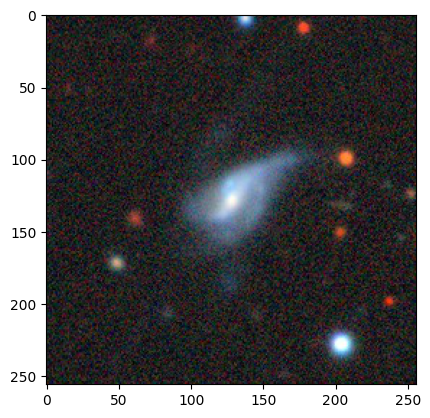

In [ ]:
plt.imshow(dataset[43]["image"]/255.0)